In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
Telco_data=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
Telco_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
Telco_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# Total Charges column is an object
Telco_data['TotalCharges']=pd.to_numeric(Telco_data['TotalCharges'],errors='coerce')

In [6]:
Telco_data['TotalCharges'].dtype

dtype('float64')

In [7]:
Telco_data.shape

(7043, 21)

In [8]:
Telco_data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [9]:
# SeniorCitizen is a categorical column
# Average monthly charges is 64.76 USD whereas 25% of population pay more than 89.85 USD
# 50% of people have tenure less than 29 months

In [10]:
Telco_data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
Telco_data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [12]:
# Checking for null values
Telco_data.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [42]:
# Since the missing rows are 11 (~0.15%), let's remove them
Telco_data=Telco_data.dropna()

In [13]:
# Checking for duplicate rows
Telco_data.duplicated().sum()

0

In [14]:
# No null values and no duplicate rows

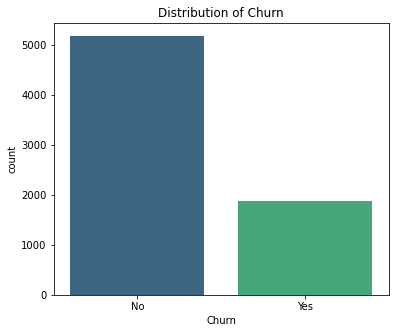

In [15]:
# Visualization of Distribution
plt.figure(figsize=(6,5))
sns.countplot(x=Telco_data['Churn'], palette='viridis', order=Telco_data['Churn'].value_counts().index)
plt.title('Distribution of Churn')
plt.show()

In [16]:
Telco_data["Churn"].value_counts()

No     5174
Yes    1869
Name: Churn, dtype: int64

In [17]:
100*Telco_data["Churn"].value_counts()/len(Telco_data["Churn"])

No     73.463013
Yes    26.536987
Name: Churn, dtype: float64

In [18]:
# Data is imbalanced
# [Churn="Yes"] : [Churn="No"] ~=27:73

In [19]:
Telco_data["SeniorCitizen"].value_counts()

0    5901
1    1142
Name: SeniorCitizen, dtype: int64

In [20]:
Telco_data["gender"].value_counts()

Male      3555
Female    3488
Name: gender, dtype: int64

In [21]:
Telco_data["MultipleLines"].value_counts()

No                  3390
Yes                 2971
No phone service     682
Name: MultipleLines, dtype: int64

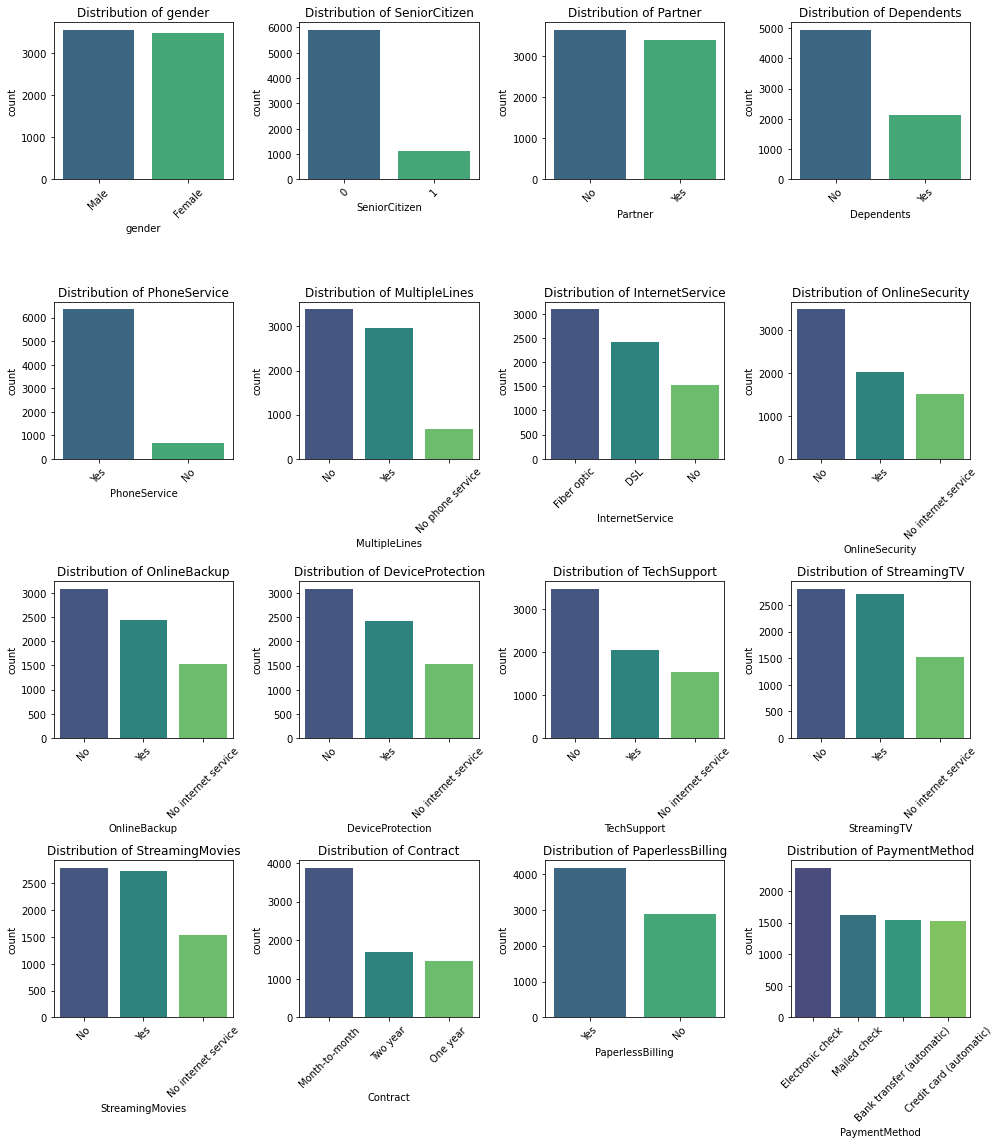

In [22]:
# Visualizing other columns

cols=['gender', 'SeniorCitizen', 'Partner', 'Dependents',
        'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod']

plt.figure(figsize=(14,16))
for i,col in enumerate(cols):
    plt.subplot(4,4,i+1)
    sns.countplot(data=Telco_data, x=col, palette='viridis', order=Telco_data[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

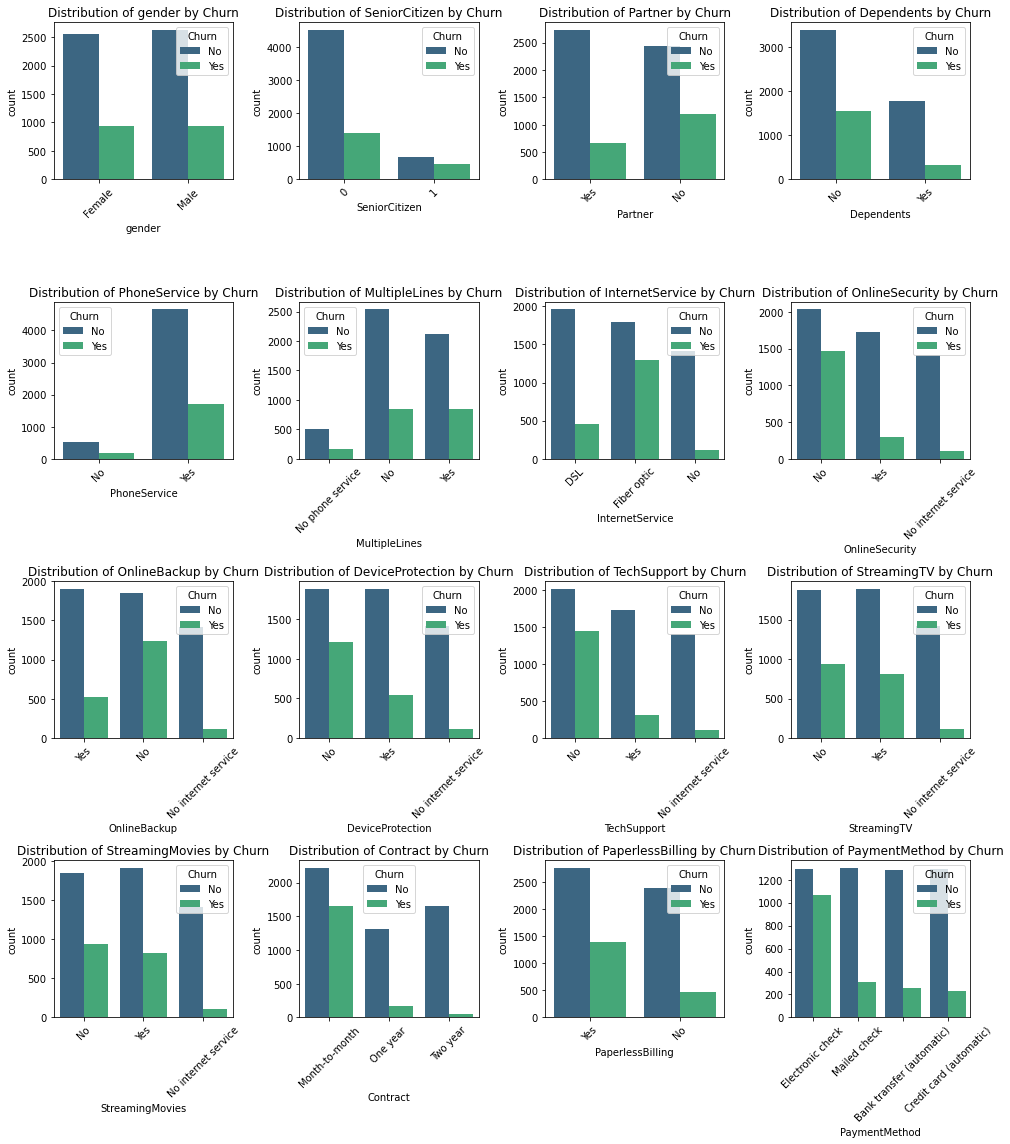

In [23]:
# With a hue of "CHURN"

# Visualizing other columns

cols=['gender', 'SeniorCitizen', 'Partner', 'Dependents',
        'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod']

plt.figure(figsize=(14,16))
for i,col in enumerate(cols):
    plt.subplot(4,4,i+1)
    sns.countplot(data=Telco_data, x=col, palette='viridis', hue='Churn')
    plt.title(f'Distribution of {col} by Churn')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
# INSIGHTS

# Customers with month-to-month contracts exhibit significantly higher churn compared to those on longer-term contracts
# Customers without online security,tech support, Online backup show noticeably higher churn meaning additional services may
#increase customer dependency on service provider.
# Automatic payment methods may indicate more stable customers, whereas electronic check users may represent more price sensitivity
# Customers with dependents show lower churn likely because of heavily relying on consistent services

# These show customers with additional services and long-term commitments tend to churn less

In [25]:
# Let's see churn rates across contracts
pd.crosstab(Telco_data['Contract'],Telco_data['Churn'],normalize='index')

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [26]:
# Contract type shows a strong relationship with customer behavior
# This indicates that longer contractual commitments substantially improve customer retention

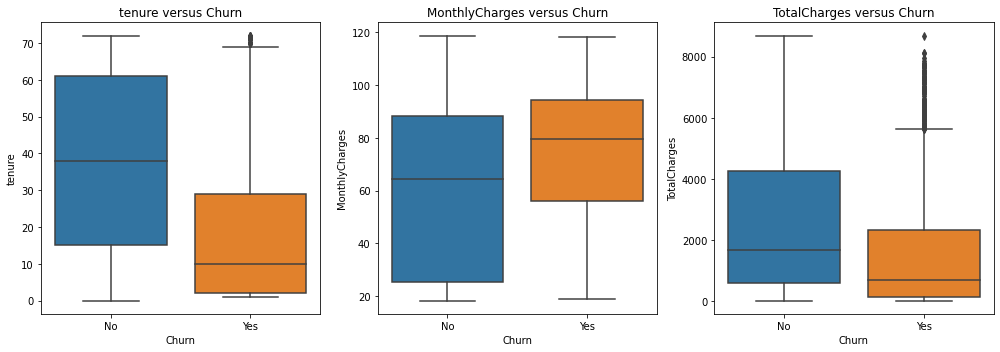

In [27]:
num_cols=['tenure','MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(14,5))
for i,col in enumerate(num_cols):
    plt.subplot(1,3,i+1)
    sns.boxplot(x='Churn', y=col, data=Telco_data)
    plt.title(f'{col} versus Churn')
plt.tight_layout()
plt.show()

In [28]:
# INSIGHTS

# Customers who churn exhibit lower tenure, indicating churn is more common among relatively new customers
# And they also show lower Total Charges. Interestingly, they tend to have very slight higher median monthly charges
# Suggesting higher recurring costs may contribute to dissatisfaction

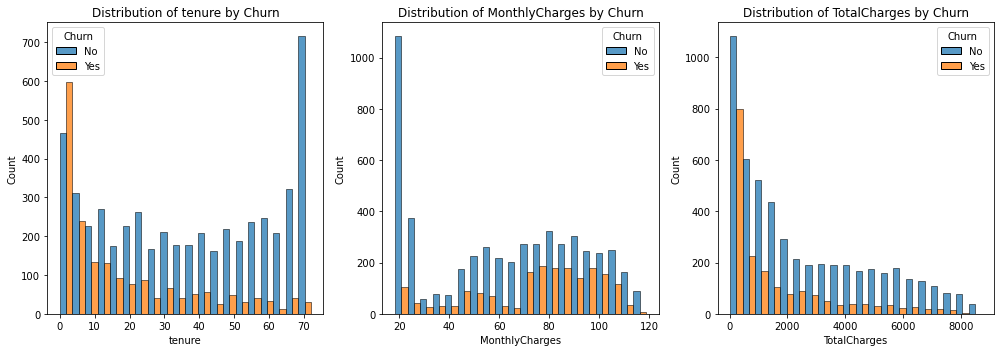

In [29]:
plt.figure(figsize=(14,5))
for i,col in enumerate(num_cols):
    plt.subplot(1,3,i+1)
    sns.histplot(hue='Churn', x=col, data=Telco_data, bins=20,multiple='dodge')
    plt.title(f'Distribution of {col} by Churn')
plt.tight_layout()
plt.show()

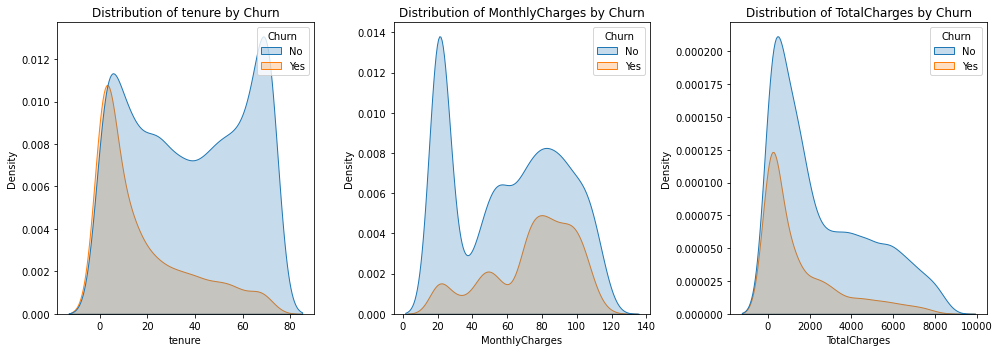

In [30]:
plt.figure(figsize=(14,5))
for i,col in enumerate(num_cols):
    plt.subplot(1,3,i+1)
    sns.kdeplot(hue='Churn', x=col, data=Telco_data, fill='True')
    plt.title(f'Distribution of {col} by Churn')
plt.tight_layout()
plt.show()

In [31]:
# The plots show that customers who do not churn dominate higher tenure and total charge ranges, reflecting longer engagement
# Churned customers are concentrated in lower tenure ranges, indicating many customers discontinue the service relatively early.

In [43]:
# Since there is a clear dominance in tenure, let's try segmenting it

Telco_data['TenureGroup']=pd.cut(Telco_data['tenure'],bins=[0,12,24,48,60,72],labels=['0-12','12-24','24-48','48-60','60-72'])

Text(0.5, 1.0, 'Churn Distribution across Tenure Groups')

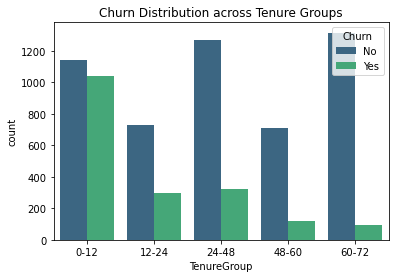

In [44]:
sns.countplot(data=Telco_data, x='TenureGroup', palette='viridis', hue='Churn')
plt.title('Churn Distribution across Tenure Groups')

In [45]:
# Calculating churn rate for better understanding
pd.crosstab(Telco_data['TenureGroup'],Telco_data['Churn'],normalize='index')

Churn,No,Yes
TenureGroup,,
0-12,0.523218,0.476782
12-24,0.712891,0.287109
24-48,0.796110,0.203890
48-60,0.855769,0.144231
60-72,0.933902,0.066098


In [35]:
# Tenure segmentation reveals a strong negative relationship between tenure and churn
# Customers within the first 12 months exhibit the highest churn rate, approximately half of the new customers discontinue early
# As tenure increases, churn rate declines steadily, reaching only 6% among customers with more than 60 months of tenure
# This suggests customer loyalty strengthens over time, and early stage is crucial for retention strategies

Text(0.5, 1.0, 'Correlation Heatmap for Numerical Features')

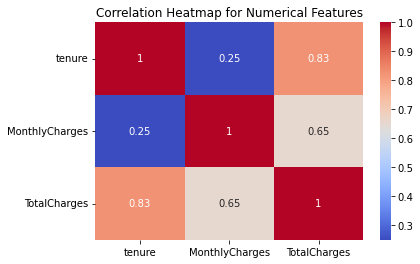

In [36]:
# Let's check correlation across numerical features
sns.heatmap(Telco_data[num_cols].corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap for Numerical Features")

In [37]:
# The heatmap reveals a strong positive relationship between tenure and total charges, which is expected since total charge
# accumulate over time. Monthly charge also shows a moderate correlation with total charges, indicating higher monthly billing
# contributes to overall spending. However, tenure and monthly charges exhibit a weak relationship, suggesting duration of a 
# customer's relationship with service is largely independent of monthly billing amount.

In [46]:
# Encoding categorical features
df_encoded=Telco_data.drop('customerID',axis=1) #customerID is just an identifier
df_encoded['Churn']=df_encoded['Churn'].map({'Yes':1,'No':0})
df_encoded=pd.get_dummies(df_encoded,drop_first=True)

In [47]:
df_encoded.shape
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_12-24,TenureGroup_24-48,TenureGroup_48-60,TenureGroup_60-72
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,1,0,1,0,0,0,0,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,1,0,0,0,0,1,0,1,0,0
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,1,0,0,1,0,0,0,0
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,1,0,0,0,0,0,0,1,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,1,0,1,0,0,0,0,0


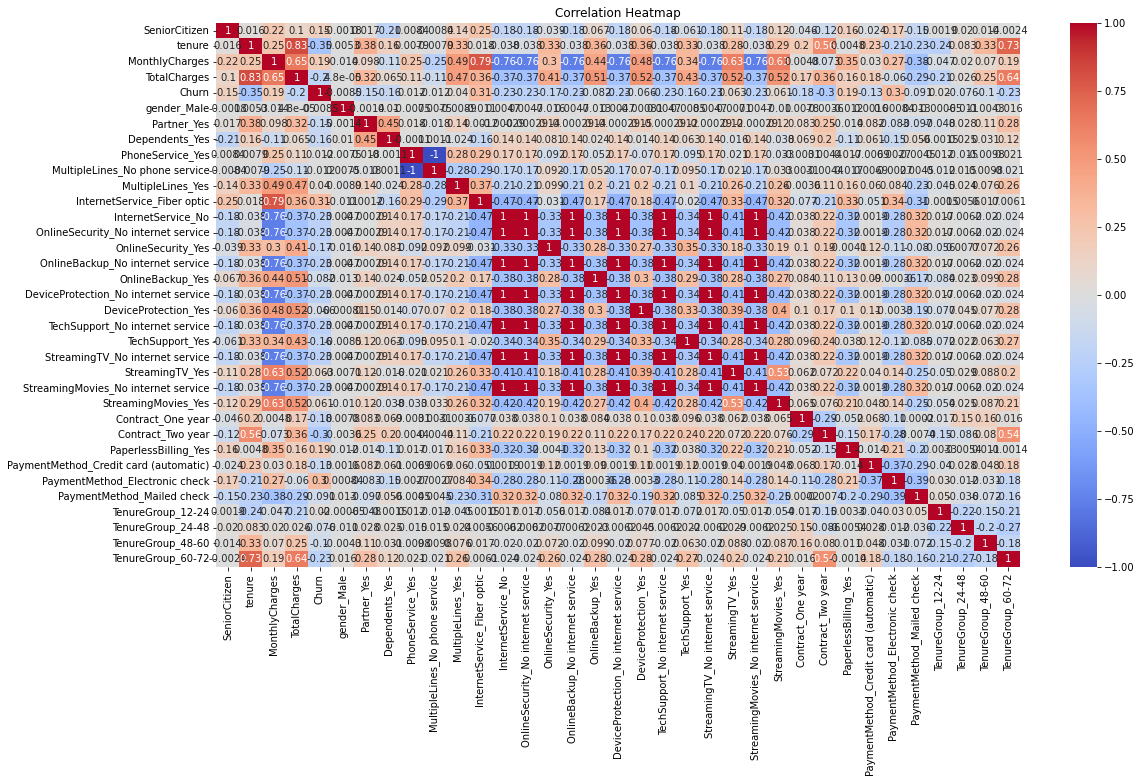

In [48]:
# Let's check correlation across all features
plt.figure(figsize=(18,10))
sns.heatmap(df_encoded.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [49]:
df_encoded.to_csv('Telco_churn.csv')